# Empirical Analysis for "Predictive conditional alphas" (Ditaso el. al 2026)

This file contains the empirical analysis for the paper "Predictive conditional alphas" by Ditaso et al. (2026). The relevant version of the paper can be found [here](bibliography/Ditaso2026_JASA.pdf).

## Methodology

### Tasks

For each asset $i$ and day $t$.

A. Get data: (see below)

1. Stock ($r_{i, t+1}$) and factor ($\bm{f}_{t+1}$) data, in 1-minute and 5-minute log-returns.
2. State variables ($C_t$).

B. Estimate betas:

1. Run a high-frequency PCA ([Ait-Sahalia 2015](bibliography/AitSahalia2015.pdf)) on the factors, storing the principal component matrices. Get all the principal components.
2. Estimate the betas with a simple regression of returns on the principal components.

C. Estimate alphas:

1. Calculate the adjusted return $\hat{Z}_{i, t+1, M} = r_{i, t+1} - \bm{f}'_{t+1}\hat{\beta}_{i, t, M}$.
2. Run simple PCA on $C_t$ and get all the principal components.
3. Calculate the estimative $\hat{\alpha}_{i,t}$. Codes will be provided.

Run all again with a 5-minute frequency ($M$) in step B.2.


### Data

- Stock returns: apparently already collected[^stock_data] from the CRSP database[^stock_sources], and processed into 1 minute and 5 minute interval log-returns. This could be re-done if necessary.
- Factors for the betas calculation: extend the paper[^factor_sources] into including more factors, at first, Fama-French 5 factors plus momentum factor. This can be found in [Saketh Aleti's data library](https://www.sakethaleti.com/data).
- State variables for the alphas calculation: defined in the paper.[^state_sources] This data will be dealt with after the calculation of betas and the adjusted returns.

[^stock_data]: From the "viktor's folder" Dropbox, data can be found in `imperial_returns_betas/5min_returns`, `imperial_returns_betas/minute_returns`, and apparently also in  `factor_neutralized_returns_DELIVERY/data/raw/trades.db`.

[^stock_sources]: From the paper: "The sample period runs from January 2001 to December 2017. After burning the first 500 days to estimate the initial conditional alphas, we end up with 2,651 trading days from January 15, 2003 to December 29, 2017. We collect tick-by-tick data for the SPY and for every stock with enough liquidity trading at AMEX, NASDAQ and NYSE (i.e., code shares 10 and 11 at the CRSP database). We consider only stocks for which we have at least 78 intraday observations (i.e., one observation every 5 minutes on average) on a given day to ensure meaningful realized beta estimates as in Amaya, Christoffersen, Jacobs and Vasquez (2015). We also allow only for a maximum number of 2.5% missing observations for each stock, resulting in a data set of 2,044 stocks (on average, 1,370 stocks per day)."

[^factor_sources]: From the paper: "To estimate daily factor loadings, we must first define which risk factors to consider. We employ a single-factor model using the SPDR S&P 500 exchange-traded fund (SPY) as a tradable proxy for the market portfolio."

[^state_sources]: From the paper: The daily frequency of the analysis dictates the choice of state variables. In particular, we consider changes in the VIX index and in the Fed Fund rate, credit and term spreads, momentum, size and value factors, short- and long-term reversal factors, and volatility risk premium (namely, difference between the VIX index and realized volatility). To avoid the curse of dimensionality, we consider only their three first principal components. [...] We gather the Fama-French, momentum and reversal factors from Kenneth French’s webpage at http://mba.tuck.dartmouth.edu/pages/faculty/ken.french/data_library.html. Interest rates are from the FRED database, whereas the VIX index is from the Chicago Board Options Exchange.

## Code setup

Modules:

In [2]:
import os
from datetime import time

import pandas as pd
import numpy as np

from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression

from typing import Tuple

Parameters:

In [3]:
DATE_START = pd.Timestamp(2001, 1, 15)
DATE_END = pd.Timestamp(2017, 12, 15)

TIME_START = time(9, 31)
TIME_END = time(16, 0)

## Factors and their principal components

### Data preprocessing

In [4]:
fct_df_raw = pd.read_csv("data/ff6_1min_returns.csv")

print(f"Data shape: {fct_df_raw.shape}")
print("First rows:")
fct_df_raw.head(3)

Data shape: (2454420, 7)
First rows:


,datetime,ff__mkt,ff__smb,ff__hml,ff__rmw,ff__cma,ff__umd
0,1996-01-02 09:30:00,-0.002509,0.001133,-0.000592,-0.000541,-0.000922,-0.003535
1,1996-01-02 09:31:00,-0.000061,0.000184,0.000053,0.000020,-0.000021,0.000204
2,1996-01-02 09:32:00,-0.000123,0.000121,-0.000045,0.000123,-0.000098,-0.000083


Formatting column types, removing first observation of the day (remove overnight returns), and reorder the data:

In [5]:
fct_df = fct_df_raw.copy()

fct_df["datetime"] = pd.to_datetime(fct_df["datetime"])
fct_df["date"] = fct_df["datetime"].dt.date
fct_df["time"] = fct_df["datetime"].dt.time

print(f"Rows sremoved: {np.sum(fct_df['time'] < TIME_START)}")
fct_df = fct_df[fct_df["time"] >= TIME_START]
# Guaranteed no observations after TIME_END

fct_df = fct_df.sort_values("datetime")

Rows sremoved: 6295


Slicing data into time window:

In [6]:
print("Dates range:", min(fct_df["date"]), " to ", max(fct_df["date"]))
print(
    "Data in the expected date range:",
    min(fct_df["date"]) <= DATE_START.date()
    and max(fct_df["date"]) >= DATE_END.date()
)

fct_df = fct_df[
    (fct_df["date"] >= DATE_START.date())
    & (fct_df["date"] <= DATE_END.date())
]

print(f"Data new shape: {fct_df.shape}")

Dates range: 1996-01-02  to  2020-12-31
Data in the expected date range: True
Data new shape: (1657360, 9)


Gaps in the time series can be seen below. Probably all are due to non-trading days, but these should be matched with gaps in the stock data to be sure.

Gaps between dates (in days): (see histogram)


<Axes: >

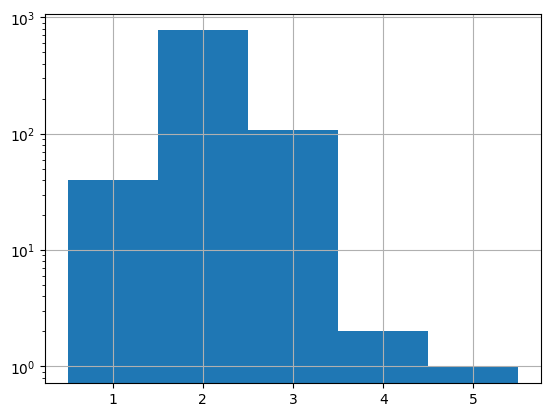

In [7]:
fct_dates_unique = fct_df["date"].unique()
fct_dates_diff = np.diff(fct_dates_unique).astype("timedelta64[D]").astype(int)

print("Gaps between dates (in days): (see histogram)")
(
    pd.Series(fct_dates_diff[fct_dates_diff > 1] - 1)
    .hist(align = "left", bins = 5, log = True)
)

Transforming returns into log-returns:

In [8]:
fct_cols = [
    col
    for col in fct_df.columns
    if col not in ["datetime", "date", "time"]
]

for col in fct_cols:
    fct_df[col] = np.log(1 + fct_df[col])

### Helper functions

Transform `time` objects into minute counts:

In [9]:
def time_as_minutes(t: time) -> int:
    return t.hour * 60 + t.minute

Aggregate data by blocks of minutes:

In [10]:
def agg_by_block(
    x: pd.DataFrame, block_minutes: int, fct_cols: list = fct_cols
) -> pd.DataFrame:
    x["block_id"] = (
        x["time"].apply(time_as_minutes) - time_as_minutes(TIME_START)
    ) // block_minutes

    agg_dict = {
        col: ("sum" if col in fct_cols else "first")
        for col in fct_cols + ["datetime", "time"]
    }

    x_agg = (x
        .groupby(["date", "block_id"])
        .agg(agg_dict)
        .reset_index()
        [["datetime", "date", "time", "block_id"] + fct_cols]
    )

    return x_agg

Count the ideal number of blocks in a day, and the true number for each day:

In [11]:
def count_blocks(
    x: np.ndarray, block_minutes: int
) -> Tuple[int, np.ndarray, np.ndarray]:
    blocks_ideal = (
        (time_as_minutes(TIME_END) - time_as_minutes(TIME_START))
        // block_minutes
        + 1
    )
    unique_days, blocks_per_day = np.unique(x, return_counts=True)
    return (blocks_ideal, unique_days, blocks_per_day) 

Analyze the frequency of blocks in the data:

In [18]:
def analyze_blocks_freq(x: pd.DataFrame, block_minutes: int) -> None:
    blocks_ideal, _, blocks_per_day = count_blocks(
        x["date"].to_numpy(), block_minutes
    )

    print(
        "Distribution of number of 5-minute blocks per day: (see histogram)",
        end = "\n\n"
    )
    pd.Series(blocks_per_day).hist(bins = 30, log = True)

    blocks_bad = blocks_per_day != blocks_ideal
    print(
        "Days with missing blocks: ",
        sum(blocks_bad),
        f" ({round(sum(blocks_bad) / len(blocks_per_day) * 100, 2)}%)",
        sep = "", end = "\n\n"
    )

    print("Dates with missing blocks:")
    dates_bad = x["date"].unique()[blocks_bad]
    for year in x["datetime"].dt.year.unique():
        dates_bad_year = list(filter(lambda x: x.year == year, dates_bad))
        if len(dates_bad_year) == 0:
            continue
        print(
            "-", ", ".join(map(lambda x: x.strftime("%d/%m/%Y"), dates_bad_year))
        )
    
    return None

Run PCA for each day:

In [21]:
def pca_daily(
    x: pd.DataFrame, block_minutes: int, pca_n_keep: int = 6,
    fct_cols: list = fct_cols, n_print: int = 500
) -> pd.DataFrame:
    blocks_ideal, _, blocks_per_day = count_blocks(
        x["date"].to_numpy(), block_minutes
    )

    dates_good = x["date"].unique()[blocks_per_day == blocks_ideal]
    pca_input = (
        x
        [x["date"].isin(dates_good)]
        [fct_cols]
        .values
        .reshape(len(dates_good), blocks_ideal, len(fct_cols))
    )

    pca_res = np.empty((len(dates_good) * blocks_ideal, pca_n_keep))

    print("Running daily PCA:")
    for i, date in enumerate(dates_good):
        if i % n_print == 0:
            print(f"- processing date {i + 1}/{len(dates_good)}: {date}")
        
        day_start = i * (blocks_ideal)
        day_end = (i + 1) * (blocks_ideal)
        #print(f"day_start: {day_start}, day_end: {day_end - 1}")

        pca_res[day_start:day_end, :] = (
            PCA(n_components = pca_n_keep)
            .fit_transform(pca_input[i])
        )

    x_pca = pd.DataFrame(pca_res)
    x_pca["date"] = np.repeat(dates_good, blocks_ideal)
    x_pca["datetime"] = x[x["date"].isin(dates_good)]["datetime"]
    #x_pca["5min_block_id"] = np.tile(np.arange(blocks_ideal), len(dates_good))
    x_pca = (
        x_pca
        [["date", "datetime"] + list(range(pca_n_keep))]
        .rename(columns = {i: f"pc{i + 1}" for i in range(pca_n_keep)})
    )
    
    return x_pca

### 1-minute frequency results

Aggregated data:

In [14]:
fct_df_1min = agg_by_block(fct_df, 1)
print(f"Data shape: {fct_df_1min.shape}")
print("First rows:")
fct_df_1min.head(7)

Data shape: (1657360, 10)
First rows:


,datetime,date,time,block_id,ff__mkt,ff__smb,ff__hml,ff__rmw,ff__cma,ff__umd
0,2001-01-16 09:31:00,2001-01-16,09:31:00,0,0.000118,-0.000215,-0.000265,0.000078,-0.000373,0.000455
1,2001-01-16 09:32:00,2001-01-16,09:32:00,1,0.000287,0.000004,-0.000337,-0.000544,-0.000372,-0.000437
2,2001-01-16 09:33:00,2001-01-16,09:33:00,2,-0.000377,0.000255,0.000197,-0.000135,0.000085,-0.000027
3,2001-01-16 09:34:00,2001-01-16,09:34:00,3,-0.001059,0.000936,0.000269,0.000141,0.000478,0.000470
4,2001-01-16 09:35:00,2001-01-16,09:35:00,4,-0.000377,0.000376,-0.000018,0.000233,-0.000219,0.000390
5,2001-01-16 09:36:00,2001-01-16,09:36:00,5,-0.000415,0.000409,-0.000202,0.000529,0.000263,0.000252
6,2001-01-16 09:37:00,2001-01-16,09:37:00,6,0.000452,-0.000627,-0.000047,0.000010,-0.000144,-0.000349


Blocks frequency issues are the same as in the 5-minute frequency, except for an added date `24/12/2007`.

Distribution of number of 5-minute blocks per day: (see histogram)

Days with missing blocks: 20 (0.47%)

Dates with missing blocks:
- 03/07/2001, 23/11/2001, 24/12/2001
- 05/07/2002, 29/11/2002, 24/12/2002
- 03/07/2003, 28/11/2003, 24/12/2003, 26/12/2003
- 26/11/2004
- 25/11/2005
- 03/07/2006, 24/11/2006
- 24/12/2007
- 27/11/2015, 24/12/2015
- 25/11/2016
- 03/07/2017, 24/11/2017


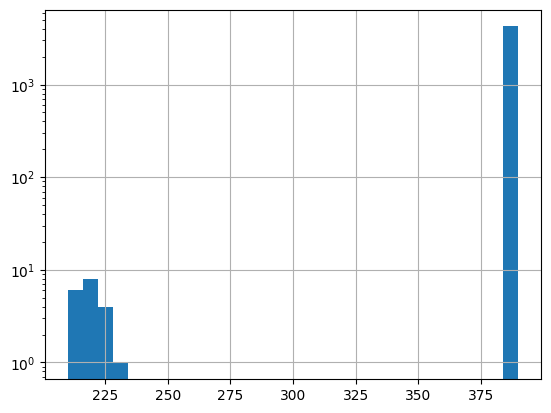

In [19]:
analyze_blocks_freq(fct_df_1min, 1)

Running PCA for each day:

In [22]:
fct_pca_1min = pca_daily(fct_df_1min, 1)

print(f"\nPCA data shape: {fct_pca_1min.shape}")
print("Data head-tail:")
fct_pca_1min

Running daily PCA:
- processing date 1/4238: 2001-01-16
- processing date 501/4238: 2003-01-24
- processing date 1001/4238: 2005-01-26
- processing date 1501/4238: 2007-01-26
- processing date 2001/4238: 2009-01-22
- processing date 2501/4238: 2011-01-14
- processing date 3001/4238: 2013-01-11
- processing date 3501/4238: 2015-01-07
- processing date 4001/4238: 2017-01-05

PCA data shape: (1652820, 8)
Data head-tail:


,date,datetime,pc1,pc2,pc3,pc4,pc5,pc6
0,2001-01-16,2001-01-16 09:31:00,0.000354,0.000381,-0.000063,-0.000213,-0.000384,-0.000138
1,2001-01-16,2001-01-16 09:32:00,0.000570,-0.000637,-0.000103,-0.000302,0.000019,-0.000032
2,2001-01-16,2001-01-16 09:33:00,-0.000451,-0.000222,0.000071,-0.000029,-0.000065,-0.000107
3,2001-01-16,2001-01-16 09:34:00,-0.001539,0.000119,-0.000178,-0.000232,-0.000151,-0.000077
4,2001-01-16,2001-01-16 09:35:00,-0.000428,0.000202,-0.000256,-0.000120,-0.000467,-0.000036
...,...,...,...,...,...,...,...,...
1652815,2017-12-15,2017-11-30 11:46:00,0.000216,0.000111,-0.000088,-0.000090,0.000091,-0.000023
1652816,2017-12-15,2017-11-30 11:47:00,0.000147,0.000108,-0.000291,0.000113,0.000015,0.000006
1652817,2017-12-15,2017-11-30 11:48:00,-0.000151,-0.000141,-0.000294,-0.000059,-0.000013,-0.000049
1652818,2017-12-15,2017-11-30 11:49:00,-0.000181,-0.000027,0.000107,0.000177,-0.000064,0.000026


### 5-minute frequency results

Aggregated data:

In [99]:
fct_df_5min = agg_by_block(fct_df, 5)
print(f"Data shape: {fct_df_5min.shape}")
print("First rows:")
fct_df_5min.head(7)

Data shape: (331477, 10)
First rows:


,datetime,date,time,block_id,ff__mkt,ff__smb,ff__hml,ff__rmw,ff__cma,ff__umd
0,2001-01-16 09:31:00,2001-01-16,09:31:00,0,-0.001408,0.001355,-0.000155,-0.000228,-0.000401,0.000851
1,2001-01-16 09:36:00,2001-01-16,09:36:00,1,-0.001131,0.000550,-0.000837,0.000889,0.001585,-0.000496
2,2001-01-16 09:41:00,2001-01-16,09:41:00,2,0.001376,-0.001767,-0.001670,-0.000062,-0.000495,0.000681
3,2001-01-16 09:46:00,2001-01-16,09:46:00,3,0.000173,0.000404,-0.000849,0.000855,0.000440,0.000035
4,2001-01-16 09:51:00,2001-01-16,09:51:00,4,-0.002096,0.001896,-0.000135,0.001722,0.001215,0.001314
5,2001-01-16 09:56:00,2001-01-16,09:56:00,5,0.001582,-0.000975,-0.001103,0.000227,-0.001050,-0.000234
6,2001-01-16 10:01:00,2001-01-16,10:01:00,6,0.002550,-0.001944,-0.001243,-0.000028,-0.001039,-0.001163


Analyzing blocks' frequency:

Distribution of number of 5-minute blocks per day: (see histogram)

Days with missing blocks: 19 (0.45%)

Dates with missing blocks:
- 03/07/2001, 23/11/2001, 24/12/2001
- 05/07/2002, 29/11/2002, 24/12/2002
- 03/07/2003, 28/11/2003, 24/12/2003, 26/12/2003
- 26/11/2004
- 25/11/2005
- 03/07/2006, 24/11/2006
- 27/11/2015, 24/12/2015
- 25/11/2016
- 03/07/2017, 24/11/2017


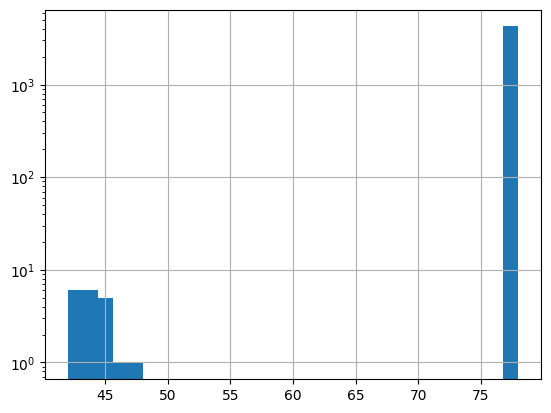

In [100]:
analyze_blocks_freq(fct_df_5min, 5)

Running PCA for each day:

In [203]:
fct_pca_5min = pca_daily(fct_df_5min, 5)

print(f"\nPCA data shape: {fct_pca_5min.shape}")
print("Data head-tail:")
fct_pca_5min

Running daily PCA:
- processing date 1/4239: 2001-01-16
- processing date 501/4239: 2003-01-24
- processing date 1001/4239: 2005-01-26
- processing date 1501/4239: 2007-01-26
- processing date 2001/4239: 2009-01-21
- processing date 2501/4239: 2011-01-13
- processing date 3001/4239: 2013-01-10
- processing date 3501/4239: 2015-01-06
- processing date 4001/4239: 2017-01-04

PCA data shape: (330642, 9)
Data head-tail:


,date,datetime,5min_block_id,pc1,pc2,pc3,pc4,pc5,pc6
0,2001-01-16,2001-01-16 09:31:00,0,-0.001473,-0.000962,-0.000388,-0.000085,-0.001057,-0.000472
1,2001-01-16,2001-01-16 09:36:00,1,-0.001309,-0.000686,0.001251,0.000246,0.001245,-0.000505
2,2001-01-16,2001-01-16 09:41:00,2,0.002407,0.000192,0.000576,0.001339,-0.000392,-0.000745
3,2001-01-16,2001-01-16 09:46:00,3,-0.000071,-0.000509,0.000999,0.000425,0.000197,0.000241
4,2001-01-16,2001-01-16 09:51:00,4,-0.003260,-0.000709,0.001257,0.000801,-0.000458,0.000067
...,...,...,...,...,...,...,...,...,...
330637,2017-12-15,2017-12-01 11:01:00,73,-0.001066,0.000687,-0.000352,0.000070,-0.000216,0.000027
330638,2017-12-15,2017-12-01 11:06:00,74,-0.000072,0.000396,-0.000167,-0.000072,-0.000088,0.000071
330639,2017-12-15,2017-12-01 11:11:00,75,-0.001046,0.000177,-0.001229,0.000041,-0.000042,0.000061
330640,2017-12-15,2017-12-01 11:16:00,76,-0.000435,0.000082,0.000054,-0.000382,-0.000219,-0.000195


## Stock returns and betas

## Helper functions

Filtering stocks on adequate ranges:

In [ ]:
def get_ok_stocks(folder: str) -> pd.DataFrame:
    paths = [
        path
        for path in os.listdir(folder)
    ]
    print(f"Number of stock files: {len(paths)}")

    ranges = []
    for path in paths:
        # Open as binary for speed
        with open("data/stocks_returns_5min/" + path, "rb") as f:
            # Skip first line (header) and read second line:
            f.readline()
            min_date = f.read(10).decode("ascii")
            
            # Seek to the end of the file and read last line:
            try:
                f.seek(-100, os.SEEK_END) # Go back 100 bytes from the end
            except OSError:
                f.seek(0) # Fallback if file is incredibly small

            max_date = f.readlines()[-1][:10].decode("ascii")
            ranges.append((min_date, max_date))

    ranges_data = pd.DataFrame(ranges, columns = ["start", "end"])
    ranges_data["start"] = pd.to_datetime(ranges_data["start"])
    ranges_data["end"] = pd.to_datetime(ranges_data["end"])
    ranges_data["stock"] = paths
    ranges_data["range_ok"] = (
        (ranges_data["start"] <= DATE_START)
        & (ranges_data["end"] >= DATE_END)
    )

    print(
        "Number of stocks present in the whole period:",
        sum(ranges_data["range_ok"])
    )

    return ranges_data[ranges_data["range_ok"]]

Run simple regression of returns on the PCs, for each stock and day, saving betas.

This could be improved by guaranteeing that the factors and stocks are already with exactly the same dates and order, and only 'good days', then, would just be needed the regression loop.

In [ ]:
def loop_betas_daily(
    paths: pd.Series, pca: pd.DataFrame,
    block_minutes: int, subpath: str,
    pc_cols: list = [f"pc{i + 1}" for i in range(6)],
    print_n: int = 50
):
    # Format PCA data as numpy:
    fct_dts = pca["datetime"].values.astype("datetime64[m]")
    fct_vals = pca[pc_cols].values

    for i, path in enumerate(paths):
        if i % print_n == 0:
            print(f"Processing stock {i + 1}/{len(paths)}: {path}")

        # Read stock data as numpy:
        stock_raw = pd.read_csv(
            "data/stocks_returns_5min/" + path,
            usecols=["datetime", "return"]
        )
        stock_dts = stock_raw["datetime"].values.astype("datetime64[m]") - np.timedelta64(4, "m")
        stock_vals = stock_raw["return"].values

        # Masks for intersection of dates:
        # Assumes PCA and stock data are sorted by datetime
        mask_stock_in_fct = np.isin(stock_dts, fct_dts)
        mask_fct_in_stock = np.isin(fct_dts, stock_dts)

        stock_dts_matched = stock_dts[mask_stock_in_fct]
        stock_vals_matched = stock_vals[mask_stock_in_fct]
        #fct_dts_matched = fct_dts[mask_fct_in_stock]
        fct_vals_matched = fct_vals[mask_fct_in_stock]

        # Mask for 'good days' with all blocks present:
        stock_days = stock_dts_matched.astype("datetime64[D]")
        blocks_ideal, unique_days, blocks_per_day = count_blocks(
            stock_days,
            block_minutes
        )

        dates_good = unique_days[blocks_per_day == blocks_ideal]
        mask_good_dates = np.isin(stock_days, dates_good)

        # Regression data:
        X = fct_vals_matched[mask_good_dates].reshape(len(dates_good), blocks_ideal, len(pc_cols))
        Y = stock_vals_matched[mask_good_dates].reshape(len(dates_good), blocks_ideal)

        # Regressions loop:
        beta_res = np.empty((len(dates_good), len(pc_cols)))
        for i, date in enumerate(dates_good):
            beta_mod = LinearRegression(fit_intercept=True)
            beta_mod.fit(X[i], Y[i])
            beta_res[i, :] = beta_mod.coef_

        np.savez_compressed(
            "data/" + subpath + path[:-4],
            betas = beta_res,
            dates = dates_good
        )

## Full exercise

Get the adequate stocks paths, then run the full exercise, with the 5-minute frequency:

In [ ]:
loop_betas_daily(
    get_ok_stocks("data/stocks_returns_5min")["stock"],
    fct_pca_5min, block_minutes = 5, subpath = "betas_5min/"
)
# Runs for ~ 1h

Processing stock 1/563: perm10108.csv
Processing stock 51/563: perm14795.csv
Processing stock 101/563: perm21928.csv
Processing stock 151/563: perm26825.csv
Processing stock 201/563: perm42200.csv
Processing stock 251/563: perm50876.csv
Processing stock 301/563: perm59396.csv
Processing stock 351/563: perm66384.csv
Processing stock 401/563: perm77418.csv
Processing stock 451/563: perm82694.csv
Processing stock 501/563: perm86845.csv
Processing stock 551/563: perm92478.csv


plot

In [ ]:
loop_betas_daily(
    get_ok_stocks("data/stocks_returns_1min")["stock"],
    fct_pca_5min, block_minutes = 1, subpath = "betas_1min/"
)
# Should run for 5 times longer

In [58]:
import aitsahaliaxiu_pca
from importlib import reload
reload(aitsahaliaxiu_pca)

<module 'aitsahaliaxiu_pca' from 'c:\\Users\\ricar\\OneDrive\\A-Trabalho\\Freelance\\ra-ditaso2026\\aitsahaliaxiu_pca.py'>

In [60]:
x_example = (
    fct_df_1min
    [fct_df_1min["date"] == fct_df_1min["date"][1]]
    [fct_cols]
    .values
)

res = aitsahaliaxiu_pca.pca_hf(x_example)
res

array([[-1.30969488e-04, -5.68688789e-04,  1.14725862e-04,
         3.25385927e-04,  1.46395516e-04, -4.47682981e-05],
       [-7.59471496e-04, -1.88554290e-04, -4.85277056e-05,
         6.90648051e-04,  4.74848734e-04, -1.61928054e-04],
       [-3.59991754e-04,  1.29831232e-04,  4.11335980e-05,
         7.29877397e-04,  5.02849615e-04, -1.77651951e-04],
       ...,
       [ 4.78596807e-03, -1.19657834e-02, -7.19068119e-03,
        -7.67246711e-03,  2.70178357e-03, -4.72853861e-03],
       [ 4.95423791e-03, -1.20646671e-02, -7.19511124e-03,
        -8.28209731e-03,  2.82983899e-03, -4.76326964e-03],
       [ 4.72325305e-03, -1.29479431e-02, -7.28457829e-03,
        -9.40915685e-03,  3.18102071e-03, -4.87070181e-03]],
      shape=(390, 6))

In [ ]:
x_step = (
    fct_df_1min
    [fct_df_1min["date"].isin(fct_df_1min["date"].unique())]
    .groupby("date")
    [fct_cols]
)
x_step = [group for _, group in x_step]

T, d = x_step[0].shape
Delta_n = 1.0 / T

k = aitsahaliaxiu_pca.get_k(Delta_n, d, T)
prev_vectors = None
last_levels = None
all_pc_matrices = []

for X_day in x_step:
    PC_day, prev_vectors = aitsahaliaxiu_pca.pca_hf_step(
        X_day, 
        k = k, 
        u = None, # Re-calculates baseline threshold daily
        prev_eigenvectors = prev_vectors, 
        initial_levels = last_levels
    )
    all_pc_matrices.append(PC_day)
    last_levels = PC_day[-1, :]

all_pc_matrices
# ~1min

[array([[-2.56793705e-04, -4.61633340e-04, -3.99639634e-04,
         -9.06570650e-05,  1.88359426e-04, -2.39928419e-05],
        [-8.56876376e-04, -1.73004042e-05, -3.28995589e-04,
         -3.44127368e-04,  6.08253675e-04,  1.10592285e-04],
        [-4.52973420e-04,  2.81300232e-04, -3.99993657e-04,
         -3.49927494e-04,  6.31254925e-04, -6.28124949e-06],
        ...,
        [ 4.77103901e-03, -1.24193099e-02, -3.22500877e-03,
         -6.54662318e-03,  4.29677937e-03, -2.28505205e-03],
        [ 4.93930885e-03, -1.25181937e-02, -3.22943882e-03,
         -7.15625338e-03,  4.42483480e-03, -2.31978309e-03],
        [ 4.70832398e-03, -1.34014697e-02, -3.31890587e-03,
         -8.28331292e-03,  4.77601652e-03, -2.42721525e-03]],
       shape=(390, 6)),
 array([[ 0.00477105, -0.01416973, -0.00342365, -0.00819358,  0.004686  ,
         -0.00247768],
        [ 0.00434675, -0.01494205, -0.00366097, -0.0075355 ,  0.00464382,
         -0.00261015],
        [ 0.00427681, -0.01548092, -0.0041

In [35]:
X = x_example
k = None
u = None
quiet = False

---

## Archive

### Example with single 5-minute stock

In [ ]:
stock_ok_5min = get_ok_stocks("data/stocks_returns_5min")

Number of stock files: 2364
Number of stocks present in the whole period: 563


In [ ]:
stock0 = pd.read_csv(stock_ok_5min["stock"].iloc[0])
stock0["datetime"] = pd.to_datetime(stock0["datetime"])
stock0 = stock0[
    (stock0["datetime"].dt.date >= DATE_START.date())
    & (stock0["datetime"].dt.date <= DATE_END.date())
]

# Ajust to same time scheme as PCA data 
stock0["datetime"] = stock0["datetime"] - pd.Timedelta(minutes = 4)

print("\nExample stock data:")
print(stock0)

Number of stock files: 2364
Number of stocks present in the whole period: 563

Example stock data:
                  datetime    return ticker  n_obs_block
702    2001-01-16 09:31:00 -0.002621    SDS            1
703    2001-01-16 09:36:00  0.001311    SDS            2
704    2001-01-16 09:41:00 -0.003940    SDS            2
705    2001-01-16 09:46:00 -0.003955    SDS            3
706    2001-01-16 09:51:00 -0.003971    SDS            4
...                    ...       ...    ...          ...
314881 2017-12-15 15:36:00  0.000487    SDS            5
314882 2017-12-15 15:41:00  0.001580    SDS            5
314883 2017-12-15 15:46:00  0.000243    SDS            5
314884 2017-12-15 15:51:00  0.000728    SDS            5
314885 2017-12-15 15:56:00 -0.000971    SDS            5

[314184 rows x 4 columns]


Analyze gaps in the stock data (if they match with the factor data gaps):

In [ ]:
print(
    "Factor dates not in stock data:",
    fct_pca_5min.shape[0]
    - sum(fct_pca_5min["datetime"].dt.date.isin(stock0["datetime"].dt.date))
)
print(
    "Stock dates not in factor data:",
    stock0.shape[0]
    - sum(stock0["datetime"].dt.date.isin(fct_pca_5min["datetime"].dt.date))
)

Factor dates not in stock data: 18619
Stock dates not in factor data: 2106


In [ ]:
stock0_merge = pd.merge(
    fct_pca_5min[["datetime"] + [f"pc{i + 1}" for i in range(6)]],
    stock0[["datetime", "return"]],
    on = "datetime", how = "left"
).dropna()
stock0_merge["date"] = stock0_merge["datetime"].dt.date

print("Merged PCA and stock data:")
stock0_merge

Merged PCA and stock data:


,datetime,pc1,pc2,pc3,pc4,pc5,pc6,return,date
0,2001-01-16 09:31:00,-0.001473,-0.000962,-0.000388,-0.000085,-0.001057,-0.000472,-0.002621,2001-01-16
1,2001-01-16 09:36:00,-0.001309,-0.000686,0.001251,0.000246,0.001245,-0.000505,0.001311,2001-01-16
2,2001-01-16 09:41:00,0.002407,0.000192,0.000576,0.001339,-0.000392,-0.000745,-0.003940,2001-01-16
3,2001-01-16 09:46:00,-0.000071,-0.000509,0.000999,0.000425,0.000197,0.000241,-0.003955,2001-01-16
4,2001-01-16 09:51:00,-0.003260,-0.000709,0.001257,0.000801,-0.000458,0.000067,-0.003971,2001-01-16
...,...,...,...,...,...,...,...,...,...
330637,2017-12-01 11:01:00,-0.001066,0.000687,-0.000352,0.000070,-0.000216,0.000027,-0.000000,2017-12-01
330638,2017-12-01 11:06:00,-0.000072,0.000396,-0.000167,-0.000072,-0.000088,0.000071,0.009007,2017-12-01
330639,2017-12-01 11:11:00,-0.001046,0.000177,-0.001229,0.000041,-0.000042,0.000061,0.004708,2017-12-01
330640,2017-12-01 11:16:00,-0.000435,0.000082,0.000054,-0.000382,-0.000219,-0.000195,0.000704,2017-12-01


In [ ]:
def betas_daily(
    x: pd.DataFrame, block_minutes: int,
    pc_cols: list = [f"pc{i + 1}" for i in range(6)], n_print: int = 500
) -> pd.DataFrame:
    blocks_ideal, _, blocks_per_day = count_blocks(x["date"].value, block_minutes)

    dates_good = x["date"].unique()[blocks_per_day == blocks_ideal]
    X = (
        x
        [x["date"].isin(dates_good)]
        [pc_cols]
        .values
        .reshape(len(dates_good), blocks_ideal, len(pc_cols))
    )
    Y = (
        x
        [x["date"].isin(dates_good)]
        ["return"]
        .values
        .reshape(len(dates_good), blocks_ideal)
    )

    beta_res = np.empty((len(dates_good), len(pc_cols)))

    print("Running daily CAPM:")
    for i, date in enumerate(dates_good):
        if i % n_print == 0:
            print(f"- processing date {i + 1}/{len(dates_good)}: {date}")

        beta_mod = LinearRegression(fit_intercept = True)
        beta_mod.fit(X[i], Y[i])

        beta_res[i, :] = beta_mod.coef_

    x_betas = pd.DataFrame(beta_res)
    x_betas["date"] = dates_good
    x_betas = x_betas.rename(columns = {i: x for i, x in enumerate(pc_cols)})
    
    return x_betas

In [ ]:
betas = betas_daily(stock0_merge, 5)

Running daily PCA:
- processing date 1/4000: 2001-01-16
- processing date 501/4000: 2003-01-24
- processing date 1001/4000: 2005-01-26
- processing date 1501/4000: 2007-12-20
- processing date 2001/4000: 2009-12-15
- processing date 2501/4000: 2011-12-08
- processing date 3001/4000: 2013-12-05
- processing date 3501/4000: 2015-12-02


       ff__mkt   ff__smb   ff__hml   ff__rmw   ff__cma   ff__umd       date
0     0.306132  0.172574  0.451437  0.241856  0.016466  1.030790 2001-01-16
1     0.273509  0.154761  1.128164  0.081101  0.243132  1.418698 2001-01-17
2     0.183545  0.396251 -1.688198  0.050770  0.353739  4.090842 2001-01-18
3     0.350833  0.175142 -1.432031 -0.438303  1.664063 -0.745708 2001-01-19
4     0.402101  1.390142 -0.441873  1.831849  0.498009  0.161516 2001-01-22
...        ...       ...       ...       ...       ...       ...        ...
3995 -0.049015 -0.077027 -0.062611 -0.509262 -0.317752  0.119217 2017-11-22
3996 -0.042401  0.089047  0.288745 -0.245875  0.294634 -0.758541 2017-11-27
3997 -0.086171  0.240852 -0.251600  0.246174 -0.309869 -0.370431 2017-11-28
3998  0.093236 -0.120183 -0.171761  0.113303 -0.396150 -0.648372 2017-11-29
3999 -0.171192 -0.012713 -0.911078 -0.168799  0.217260 -0.709472 2017-11-30

[4000 rows x 7 columns]


<Axes: xlabel='date'>

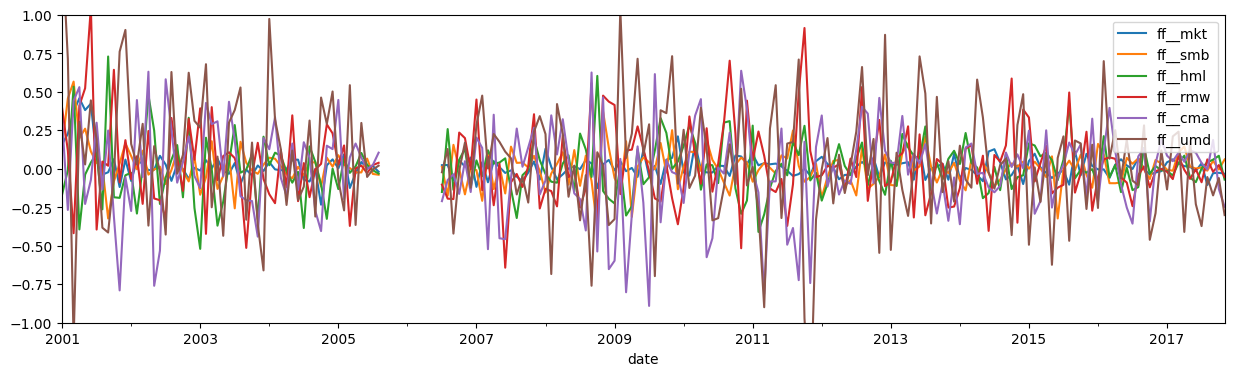

In [ ]:
print(betas)

(
    betas
    .groupby(pd.Grouper(key="date", freq="ME"))
    .mean()
    .plot.line(ylim = (-1, 1), figsize = (15, 4))
)